In [17]:
import os

import pandas as pd
import numpy as np
import dataset as ds
import mne
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
mne.set_log_level('CRITICAL')

sns.set_theme(
    context='notebook',
    style='ticks',
    palette='deep',
    font='Arial',
    font_scale=1,
    color_codes=True,
    rc={'axes.unicode_minus': False}
)

In [19]:
df_info = ds.load_info()
df_info

,Genotype
Monkeys,
0629#,Mutant
0635#,Mutant
0741#,Mutant
0760#,Mutant
0767#,Mutant
0771#,Mutant
0800#,Mutant
0805#,Mutant
0628#,WT


In [20]:
import glob

files = glob.glob(os.path.join(ds.path['tmp'], '**', 'raw.edf'), recursive=True)
df_info = ds.load_info()
df_sessions = pd.DataFrame()

for file in files:
    animal, session = np.array(file.split('\\'))[[-3, -2]]
    group = df_info.loc[animal, 'Genotype']

    fname = os.path.join(ds.path['tmp'], animal, session, 'raw.edf')
    raw = mne.io.read_raw_edf(fname)

    # session table
    session_length = raw.times[-1]
    df_sessions_tmp = pd.DataFrame({
        'animal_id': animal,
        'genotype': group,
        'session': session,
        'session_length': session_length
    }, index=[0])
    df_sessions = pd.concat([df_sessions, df_sessions_tmp])

df_sessions = df_sessions.reset_index(drop=True)
pd.concat([df_sessions.head(2), df_sessions.tail(2)])

,animal_id,genotype,session,session_length
0,0628#,WT,2024-03-14,2781.996
1,0628#,WT,2024-04-07,4515.996
103,0805#,Mutant,2024-03-31,4366.996
104,0805#,Mutant,2024-06-21,14340.996


In [5]:
df_sessions.to_excel(os.path.join(ds.path['tbl'], 'sessions.xlsx'))

## prep annot

In [21]:
path = os.path.join(ds.path['tmp'], 'prep', 'annot_over_loco')
# os.makedirs(path)

In [22]:
from prep import find_over_thr_segs

seg_duration = 2
animals = df_sessions['animal_id'].unique()
df_power = pd.DataFrame()

for animal in animals:
    sessions = df_sessions.query('animal_id == @animal')['session'].unique()
    genotype = df_sessions.query('animal_id == @animal')['genotype'].iloc[0]

    for session in sessions:
        fname = os.path.join(ds.path['tmp'], animal, session, 'raw.edf')
        raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)

        raw.set_channel_types({'Loco': 'bio'})
        raw.notch_filter(50)
        
        epochs = mne.make_fixed_length_epochs(raw.copy().filter(0.1, 40), duration=seg_duration, preload=True, id=0)
        epochs.drop_bad(flat=dict(eeg=5e-6), reject={'bio': 5e-6, 'eeg': 1000e-6}) 
        epochs.save(os.path.join(path, f'{animal}_{session}_epochs.fif'), overwrite=True)
        # if len(epochs) == 0:
        #     print(f'No data left in {animal} on {session}')
        #     continue
        #     
        # power_epochs = epochs.compute_psd(fmax=30, method='welch', n_fft=1000)
        # df_power_session = power_epochs.to_data_frame()
        # df_power_session = df_power_session.rename(columns={'condition': 'animal', power_epochs.ch_names[0]:'power'})
        # df_power_session['animal'] = animal
        # df_power_session['genotype'] = genotype
        # 
        # df_power = pd.concat([df_power, df_power_session])
        



ValueError: If n_per_seg is None n_fft is not allowed to be > n_times. If you want zero-padding, you have to set n_per_seg to relevant length. Got n_fft of 1000 while signal length is 500.

<Axes: xlabel='freq', ylabel='power'>

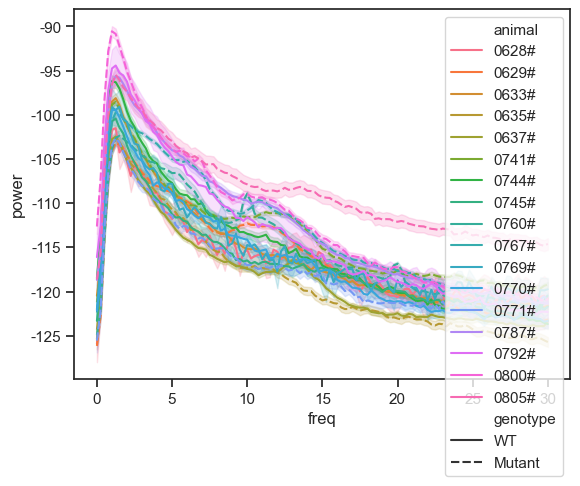

In [71]:
df_power['power'] = 10 * np.log10(df_power['power'])
sns.lineplot(
    data=df_power,
    x='freq',
    y='power',
    hue='animal',
    style='genotype'
    
    
)

In [32]:
power_epochs = epochs.compute_psd()
df_power = power_epochs.to_data_frame()

In [53]:
df_power

,genotype,epoch,freq,power
0,WT,101,0.0,-117.365981
1,WT,101,0.5,-112.923898
2,WT,101,1.0,-100.784958
3,WT,101,1.5,-97.397255
4,WT,101,2.0,-100.919183
...,...,...,...,...
19393,Mutant,1391,28.0,-116.074323
19394,Mutant,1391,28.5,-116.947033
19395,Mutant,1391,29.0,-115.087762
19396,Mutant,1391,29.5,-114.628202


<Axes: xlabel='animal', ylabel='power'>

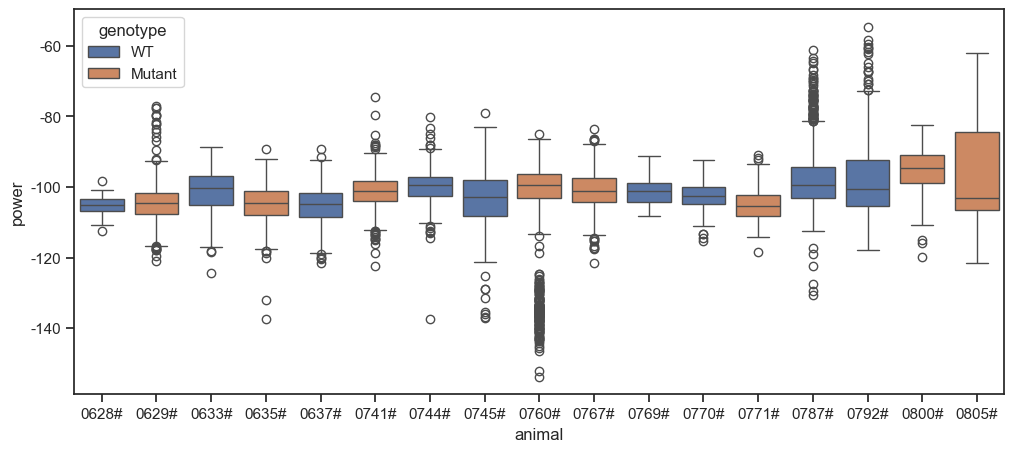

In [72]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df_power.query('freq == 2'),
    x='animal',
    y='power',
    hue='genotype'
)

In [ ]:
df_power.query('freq == 2')

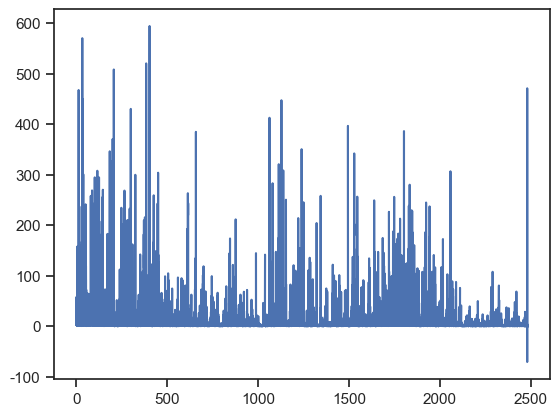

In [14]:
plt.plot(raw.times, raw.copy().pick([1]).get_data().squeeze() * 1e6)
plt.show()